# Classification with K-Nearest Neighbors and Radius Neighbors
**Student Name:** Sandesh Ghimire  

---

## Step 1: Load and Prepare the Dataset

The Wine dataset records thirteen chemical measurements taken from 178 Italian wines grown by three different cultivars. The task is to recover the cultivar from the chemistry alone.

Both classifiers studied here decide by proximity, so the geometry of the feature space determines everything. That makes the *scale* of each feature worth inspecting before any model is fitted, and it turns out to be the single most consequential property of this dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
df['cultivar'] = [wine.target_names[i] for i in y]

print("Dataset Shape:", X.shape)
print("Number of Features:", len(wine.feature_names))
print("Number of Classes :", len(wine.target_names))
print("\nFirst Five Rows:")
print(df.head())

Dataset Shape: (178, 13)
Number of Features: 13
Number of Classes : 3

First Five Rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82  

In [2]:
# Class distribution
print("Class Distribution:")
print("=" * 55)
counts = df['cultivar'].value_counts().sort_index()
for name, n in counts.items():
    print(f"  {name:10} {n:4d} samples  ({n/len(df)*100:5.1f}%)")

print(f"\nTotal: {len(df)} samples")
print(f"Majority-class baseline: {counts.max()/len(df):.4f}")
print("\nThe classes are moderately imbalanced but none is rare, so plain accuracy is a")
print("reasonable headline metric. Any model worth keeping must beat the baseline above,")
print("which is what a classifier that always guessed the largest class would score.")

Class Distribution:
  class_0      59 samples  ( 33.1%)
  class_1      71 samples  ( 39.9%)
  class_2      48 samples  ( 27.0%)

Total: 178 samples
Majority-class baseline: 0.3989

The classes are moderately imbalanced but none is rare, so plain accuracy is a
reasonable headline metric. Any model worth keeping must beat the baseline above,
which is what a classifier that always guessed the largest class would score.


In [3]:
# Feature summary - note the wildly different scales
print("Feature Ranges:")
print("=" * 78)
print(f"{'feature':32} {'min':>10} {'max':>10} {'mean':>10} {'std':>10}")
print("-" * 78)
for i, name in enumerate(wine.feature_names):
    col = X[:, i]
    print(f"{name:32} {col.min():10.2f} {col.max():10.2f} {col.mean():10.2f} {col.std():10.2f}")

# Share of total variance carried by each feature
var = X.var(axis=0)
share = var / var.sum() * 100
order = np.argsort(share)[::-1]

print("\nShare of Total Variance (unscaled):")
print("=" * 55)
for i in order[:5]:
    print(f"  {wine.feature_names[i]:32} {share[i]:7.3f}%")
print(f"  {'... all remaining features':32} {share[order[5:]].sum():7.3f}%")

print("\nThis is the decisive fact for this lab. Proline is measured in the hundreds while")
print("most other features sit between 0 and 5, so it carries almost all the variance.")
print("Euclidean distance on raw features is therefore very nearly a one-dimensional")
print("measurement of proline, and the other twelve features barely register.")

Feature Ranges:
feature                                 min        max       mean        std
------------------------------------------------------------------------------
alcohol                               11.03      14.83      13.00       0.81
malic_acid                             0.74       5.80       2.34       1.11
ash                                    1.36       3.23       2.37       0.27
alcalinity_of_ash                     10.60      30.00      19.49       3.33
magnesium                             70.00     162.00      99.74      14.24
total_phenols                          0.98       3.88       2.30       0.62
flavanoids                             0.34       5.08       2.03       1.00
nonflavanoid_phenols                   0.13       0.66       0.36       0.12
proanthocyanins                        0.41       3.58       1.59       0.57
color_intensity                        1.28      13.00       5.06       2.31
hue                                    0.48       1.71    

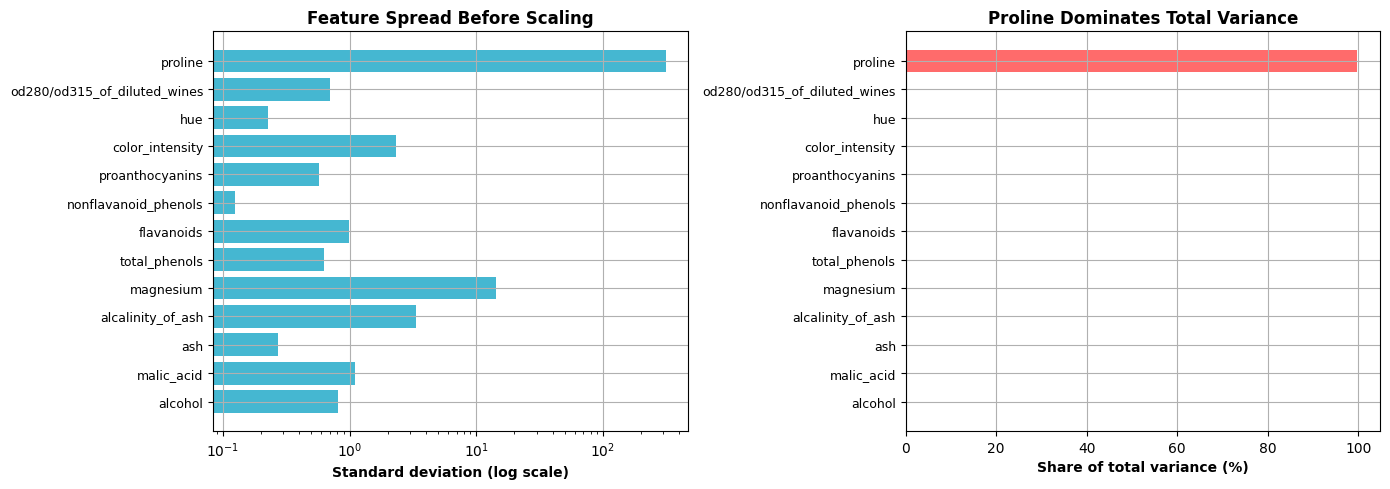

Left: standard deviations span four orders of magnitude, so a log axis is needed.
Right: on a linear axis proline's bar is the only one visible.


In [4]:
# Visualise the scale disparity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(len(wine.feature_names)), X.std(axis=0), color='#45B7D1')
axes[0].set_yticks(range(len(wine.feature_names)))
axes[0].set_yticklabels(wine.feature_names, fontsize=9)
axes[0].set_xscale('log')
axes[0].set_xlabel('Standard deviation (log scale)', fontweight='bold')
axes[0].set_title('Feature Spread Before Scaling', fontweight='bold')

axes[1].barh(range(len(wine.feature_names)), share, color='#FF6B6B')
axes[1].set_yticks(range(len(wine.feature_names)))
axes[1].set_yticklabels(wine.feature_names, fontsize=9)
axes[1].set_xlabel('Share of total variance (%)', fontweight='bold')
axes[1].set_title('Proline Dominates Total Variance', fontweight='bold')

plt.tight_layout()
plt.show()

print("Left: standard deviations span four orders of magnitude, so a log axis is needed.")
print("Right: on a linear axis proline's bar is the only one visible.")

In [5]:
# Split into 80% training and 20% testing, preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

print("\nClass balance preserved by stratification:")
print(f"{'class':12} {'train':>8} {'test':>8}")
print("-" * 30)
for i, name in enumerate(wine.target_names):
    print(f"{name:12} {(y_train==i).sum():8d} {(y_test==i).sum():8d}")

baseline = np.bincount(y_test).max() / len(y_test)
print(f"\nTest-set majority baseline: {baseline:.4f}")
print(f"Test set holds {len(y_test)} samples, so a single correct prediction is worth")
print(f"{1/len(y_test)*100:.2f} percentage points. Small differences between models are noise.")

Training set: (142, 13)
Test set    : (36, 13)

Class balance preserved by stratification:
class           train     test
------------------------------
class_0            47       12
class_1            57       14
class_2            38       10

Test-set majority baseline: 0.3889
Test set holds 36 samples, so a single correct prediction is worth
2.78 percentage points. Small differences between models are noise.


---
## Step 2: Implement K-Nearest Neighbors (KNN)

KNN assigns each test point the majority label among its `k` closest training points. The count is fixed, so every prediction rests on exactly `k` votes regardless of how crowded or sparse that region of the feature space happens to be.

Following the lab brief, models are fitted on the raw unscaled features.

In [6]:
k_values = [1, 5, 11, 15, 21]
knn_results = []

print("K-Nearest Neighbors - Unscaled Features")
print("=" * 55)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_results.append({'k': k, 'accuracy': acc,
                        'correct': int(acc * len(y_test)), 'n': len(y_test)})
    print(f"  k = {k:3d}   accuracy = {acc:.4f}   ({int(round(acc*len(y_test)))}/{len(y_test)} correct)")

knn_df = pd.DataFrame(knn_results)
print("\nSummary Table:")
print(knn_df.to_string(index=False))

best = knn_df.loc[knn_df['accuracy'].idxmax()]
print(f"\nBest k: {int(best['k'])} with accuracy {best['accuracy']:.4f}")

K-Nearest Neighbors - Unscaled Features
  k =   1   accuracy = 0.7778   (28/36 correct)
  k =   5   accuracy = 0.8056   (29/36 correct)
  k =  11   accuracy = 0.8056   (29/36 correct)
  k =  15   accuracy = 0.8056   (29/36 correct)
  k =  21   accuracy = 0.8056   (29/36 correct)

Summary Table:
 k  accuracy  correct  n
 1  0.777778       28 36
 5  0.805556       29 36
11  0.805556       29 36
15  0.805556       29 36
21  0.805556       29 36

Best k: 5 with accuracy 0.8056


In [7]:
# Inspect where the errors fall for a representative k
model = KNeighborsClassifier(n_neighbors=11).fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Confusion Matrix (k = 11, unscaled):")
print("=" * 55)
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm,
                   index=[f'true_{n}' for n in wine.target_names],
                   columns=[f'pred_{n}' for n in wine.target_names]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Confusion Matrix (k = 11, unscaled):
              pred_class_0  pred_class_1  pred_class_2
true_class_0            12             0             0
true_class_1             0             8             6
true_class_2             1             0             9

Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.57      0.73        14
     class_2       0.60      0.90      0.72        10

    accuracy                           0.81        36
   macro avg       0.84      0.82      0.80        36
weighted avg       0.86      0.81      0.80        36



---
## Step 3: Implement Radius Neighbors (RNN)

RNN inverts the rule: instead of a fixed number of neighbours it counts every training point within a fixed radius. The vote size therefore varies from point to point, which is the source of both its appeal and its fragility.

The radii prescribed by the lab brief (350 to 600) look enormous until one recalls the variance result from Step 1. Because proline dominates the distance calculation, these radii are effectively measured in proline units, where a spread of a few hundred is ordinary.

In [8]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_results = []

print("Radius Neighbors - Unscaled Features")
print("=" * 55)

for r in radius_values:
    # outlier_label='most_frequent' prevents a crash when a test point has no
    # neighbour inside the radius; without it sklearn raises ValueError.
    model = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_results.append({'radius': r, 'accuracy': acc})
    print(f"  radius = {r:4d}   accuracy = {acc:.4f}   ({int(round(acc*len(y_test)))}/{len(y_test)} correct)")

rnn_df = pd.DataFrame(rnn_results)
print("\nSummary Table:")
print(rnn_df.to_string(index=False))

best_r = rnn_df.loc[rnn_df['accuracy'].idxmax()]
print(f"\nBest radius: {int(best_r['radius'])} with accuracy {best_r['accuracy']:.4f}")

Radius Neighbors - Unscaled Features
  radius =  350   accuracy = 0.7222   (26/36 correct)
  radius =  400   accuracy = 0.6944   (25/36 correct)
  radius =  450   accuracy = 0.6944   (25/36 correct)
  radius =  500   accuracy = 0.6944   (25/36 correct)
  radius =  550   accuracy = 0.6667   (24/36 correct)
  radius =  600   accuracy = 0.6667   (24/36 correct)

Summary Table:
 radius  accuracy
    350  0.722222
    400  0.694444
    450  0.694444
    500  0.694444
    550  0.666667
    600  0.666667

Best radius: 350 with accuracy 0.7222


In [9]:
# Diagnostic: how many training points actually fall inside each radius?
nn = NearestNeighbors().fit(X_train)

print("Neighbourhood Sizes by Radius")
print("=" * 72)
print(f"{'radius':>8} {'min':>8} {'mean':>9} {'max':>8} {'empty':>8} {'% of train':>12}")
print("-" * 72)

for r in radius_values:
    neigh = nn.radius_neighbors(X_test, radius=r, return_distance=False)
    sizes = np.array([len(a) for a in neigh])
    print(f"{r:8d} {sizes.min():8d} {sizes.mean():9.1f} {sizes.max():8d} "
          f"{(sizes==0).sum():8d} {sizes.mean()/len(X_train)*100:11.1f}%")

print("\nThis table explains the accuracy trend. Even the smallest prescribed radius pulls in")
print("well over half the training set for a typical test point, and the largest pulls in")
print("nearly four fifths. These are not local neighbourhoods in any meaningful sense: the")
print("model is averaging over most of the data, so its predictions drift toward the overall")
print("class distribution and detail is washed out. No test point is ever left stranded")
print("without neighbours at these radii, so the outlier fallback never actually fires here.")

Neighbourhood Sizes by Radius
  radius      min      mean      max    empty   % of train
------------------------------------------------------------------------
     350        4      80.5      111        0        56.7%
     400        9      87.9      121        0        61.9%
     450       14      94.8      126        0        66.8%
     500       17     100.1      136        0        70.5%
     550       19     106.0      138        0        74.6%
     600       23     111.0      140        0        78.1%

This table explains the accuracy trend. Even the smallest prescribed radius pulls in
well over half the training set for a typical test point, and the largest pulls in
nearly four fifths. These are not local neighbourhoods in any meaningful sense: the
model is averaging over most of the data, so its predictions drift toward the overall
class distribution and detail is washed out. No test point is ever left stranded
without neighbours at these radii, so the outlier fallback never

---
## Step 4: Visualize and Compare Results

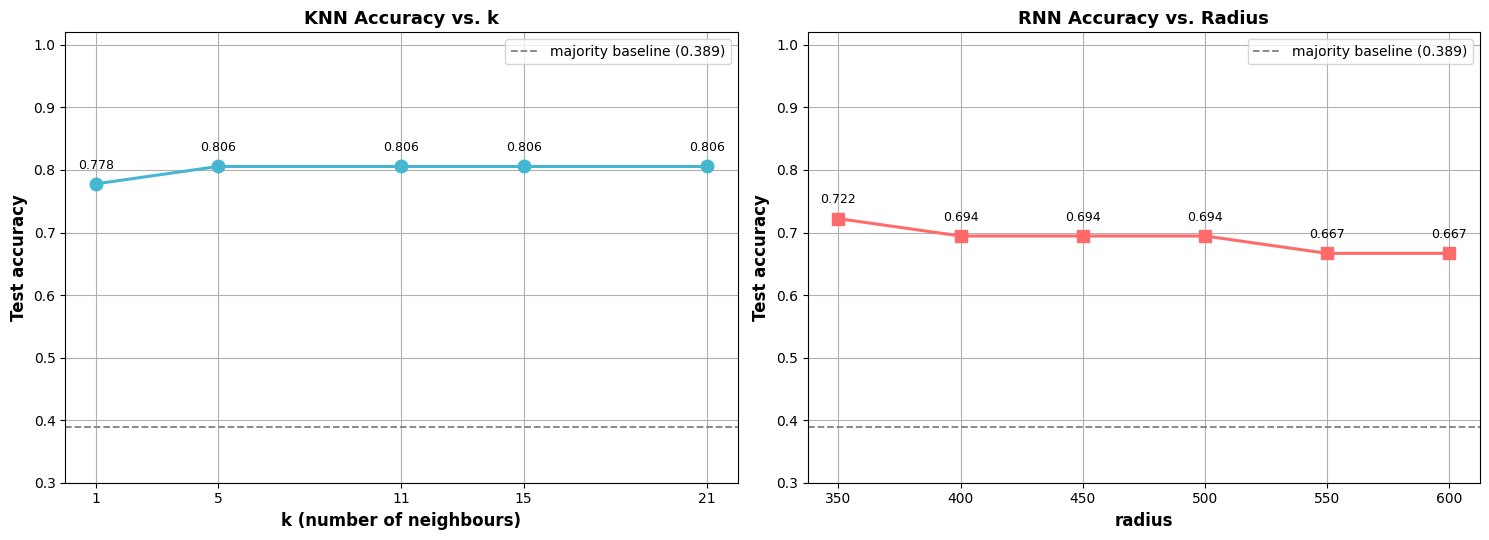

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# KNN trend
axes[0].plot(knn_df['k'], knn_df['accuracy'], marker='o', linewidth=2.2,
             markersize=9, color='#45B7D1')
axes[0].axhline(baseline, color='gray', linestyle='--', linewidth=1.3,
                label=f'majority baseline ({baseline:.3f})')
axes[0].set_xlabel('k (number of neighbours)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Test accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('KNN Accuracy vs. k', fontsize=13, fontweight='bold')
axes[0].set_xticks(k_values)
axes[0].set_ylim(0.3, 1.02)
axes[0].legend()
for _, row in knn_df.iterrows():
    axes[0].annotate(f"{row['accuracy']:.3f}", (row['k'], row['accuracy']),
                     textcoords="offset points", xytext=(0, 11), ha='center', fontsize=9)

# RNN trend
axes[1].plot(rnn_df['radius'], rnn_df['accuracy'], marker='s', linewidth=2.2,
             markersize=9, color='#FF6B6B')
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1.3,
                label=f'majority baseline ({baseline:.3f})')
axes[1].set_xlabel('radius', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Test accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('RNN Accuracy vs. Radius', fontsize=13, fontweight='bold')
axes[1].set_xticks(radius_values)
axes[1].set_ylim(0.3, 1.02)
axes[1].legend()
for _, row in rnn_df.iterrows():
    axes[1].annotate(f"{row['accuracy']:.3f}", (row['radius'], row['accuracy']),
                     textcoords="offset points", xytext=(0, 11), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

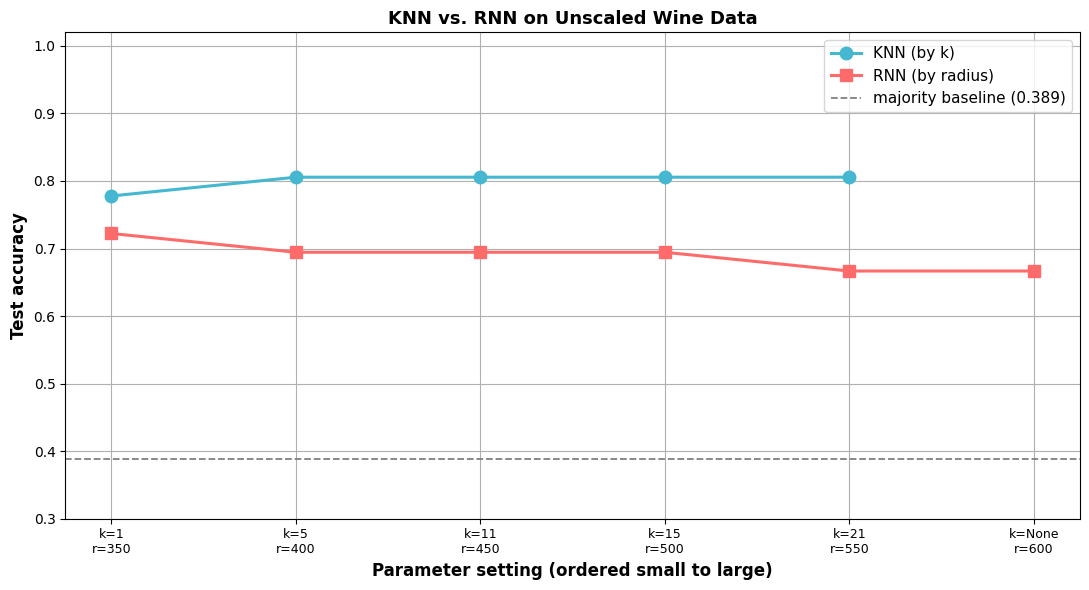

KNN range: 0.7778 to 0.8056
RNN range: 0.6667 to 0.7222

KNN beats RNN at every setting tried, by roughly 11.0 percentage points on average.


In [11]:
# Both models on one axis, using a shared normalised parameter position
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(range(len(k_values)), knn_df['accuracy'], marker='o', linewidth=2.2,
        markersize=9, label='KNN (by k)', color='#45B7D1')
ax.plot(range(len(radius_values)), rnn_df['accuracy'], marker='s', linewidth=2.2,
        markersize=9, label='RNN (by radius)', color='#FF6B6B')
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.3,
           label=f'majority baseline ({baseline:.3f})')

ax.set_xlabel('Parameter setting (ordered small to large)', fontsize=12, fontweight='bold')
ax.set_ylabel('Test accuracy', fontsize=12, fontweight='bold')
ax.set_title('KNN vs. RNN on Unscaled Wine Data', fontsize=13, fontweight='bold')
ax.set_xticks(range(max(len(k_values), len(radius_values))))
ax.set_xticklabels([f'k={k}\nr={r}' if i < len(radius_values) else f'k={k}'
                    for i, (k, r) in enumerate(zip(k_values + [None],
                                                   radius_values))][:len(radius_values)],
                   fontsize=9)
ax.set_ylim(0.3, 1.02)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"KNN range: {knn_df['accuracy'].min():.4f} to {knn_df['accuracy'].max():.4f}")
print(f"RNN range: {rnn_df['accuracy'].min():.4f} to {rnn_df['accuracy'].max():.4f}")
print(f"\nKNN beats RNN at every setting tried, by roughly "
      f"{(knn_df['accuracy'].mean() - rnn_df['accuracy'].mean())*100:.1f} percentage points on average.")

### Observations

**KNN is flat after k = 1.** Accuracy rises slightly from k = 1 to k = 5 and then stops moving. k = 1 is the only setting that underperforms, which is the expected signature of overfitting: a single neighbour lets one mislabelled or unusual training wine dictate a prediction. Adding votes smooths that away immediately, and beyond k = 5 the extra neighbours change no decisions.

**RNN degrades as the radius grows.** Accuracy falls steadily from radius 350 onward. The neighbourhood-size diagnostic in Step 3 explains why: at radius 350 an average test point already sees more than half the training set, and by 600 it sees close to four fifths. Once the neighbourhood approaches the whole dataset, every point receives nearly the same vote and the model slides toward simply predicting the most common class.

**KNN wins at every setting tested here.** That result is specific to this configuration rather than a general law, and the reason is worth drawing out.

**Both models are held back by the same thing.** Neither exceeds the low 0.80s, which is poor for a dataset this separable. The cause is the variance result from Step 1: unscaled Euclidean distance is dominated by proline, so twelve of the thirteen measurements are effectively discarded. The section below tests that diagnosis directly.

In [12]:
# Does feature scaling explain the ceiling? Fit the same KNN inside a scaling pipeline.
print("Effect of Feature Scaling on KNN")
print("=" * 62)
print(f"{'k':>4} {'unscaled':>12} {'scaled':>12} {'change':>12}")
print("-" * 62)

scaled_knn = []
for k in k_values:
    raw = accuracy_score(y_test, KNeighborsClassifier(n_neighbors=k)
                         .fit(X_train, y_train).predict(X_test))
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    sc = accuracy_score(y_test, pipe.fit(X_train, y_train).predict(X_test))
    scaled_knn.append(sc)
    print(f"{k:4d} {raw:12.4f} {sc:12.4f} {sc-raw:+12.4f}")

print("\nScaling lifts accuracy dramatically. Once every feature contributes on equal terms,")
print("the other twelve measurements re-enter the distance calculation and the three")
print("cultivars turn out to be almost perfectly separable.")

Effect of Feature Scaling on KNN
   k     unscaled       scaled       change
--------------------------------------------------------------
   1       0.7778       0.9722      +0.1944
   5       0.8056       0.9722      +0.1667
  11       0.8056       1.0000      +0.1944
  15       0.8056       1.0000      +0.1944
  21       0.8056       1.0000      +0.1944

Scaling lifts accuracy dramatically. Once every feature contributes on equal terms,
the other twelve measurements re-enter the distance calculation and the three
cultivars turn out to be almost perfectly separable.


In [13]:
# Scaling changes what a sensible radius even means
print("RNN on Scaled Features")
print("=" * 62)
print("After standardisation the prescribed radii of 350-600 are meaningless: every point")
print("lies within a distance of roughly 10 of every other. Smaller radii are required.\n")

scaled_radii = [2, 3, 4, 5, 6, 8]
scaled_rnn = []
print(f"{'radius':>8} {'accuracy':>12}")
print("-" * 24)
for r in scaled_radii:
    pipe = make_pipeline(StandardScaler(),
                         RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent'))
    acc = accuracy_score(y_test, pipe.fit(X_train, y_train).predict(X_test))
    scaled_rnn.append(acc)
    print(f"{r:8d} {acc:12.4f}")

print("\nRNN now peaks competitively but collapses once the radius grows too large, landing")
print(f"exactly on the majority-class baseline of {baseline:.4f} at radius 8. That is the model")
print("becoming fully degenerate: the neighbourhood has swallowed the entire training set,")
print("so every test point receives an identical vote and the prediction never varies.")

RNN on Scaled Features
After standardisation the prescribed radii of 350-600 are meaningless: every point
lies within a distance of roughly 10 of every other. Smaller radii are required.

  radius     accuracy
------------------------
       2       0.8611
       3       0.9722
       4       0.9444
       5       0.8611
       6       0.7500
       8       0.3889

RNN now peaks competitively but collapses once the radius grows too large, landing
exactly on the majority-class baseline of 0.3889 at radius 8. That is the model
becoming fully degenerate: the neighbourhood has swallowed the entire training set,
so every test point receives an identical vote and the prediction never varies.


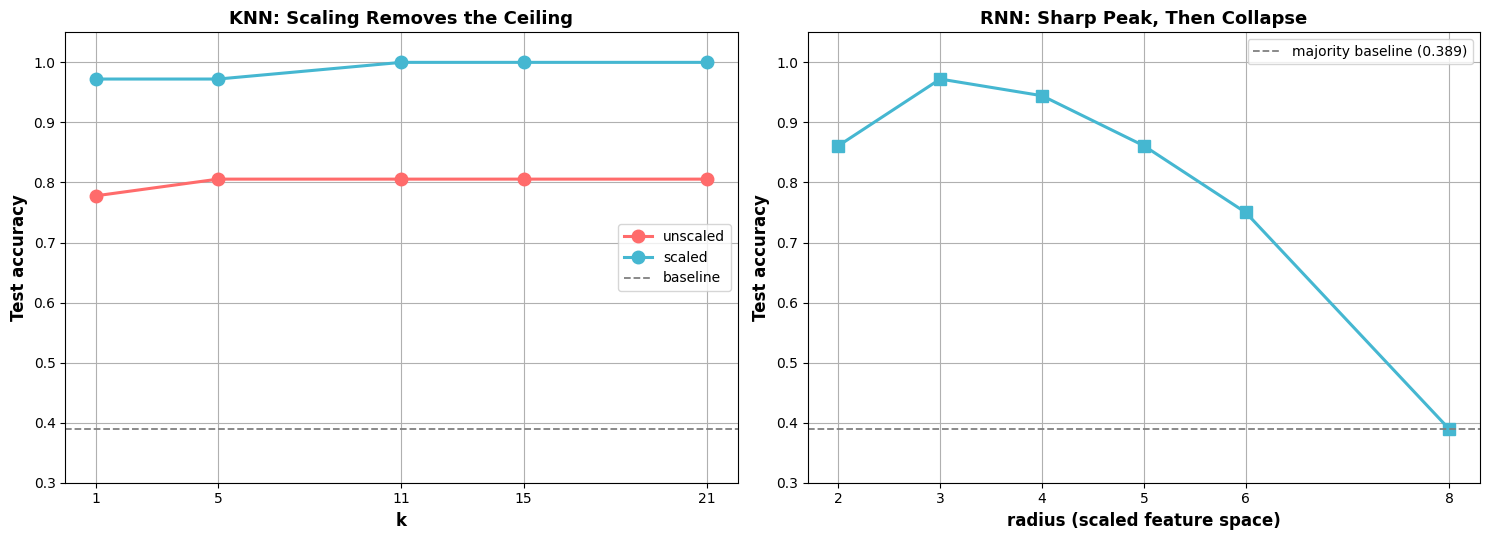

In [14]:
# Side-by-side view of the scaled results
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(k_values, knn_df['accuracy'], marker='o', linewidth=2.2, markersize=9,
             label='unscaled', color='#FF6B6B')
axes[0].plot(k_values, scaled_knn, marker='o', linewidth=2.2, markersize=9,
             label='scaled', color='#45B7D1')
axes[0].axhline(baseline, color='gray', linestyle='--', linewidth=1.3, label='baseline')
axes[0].set_xlabel('k', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Test accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('KNN: Scaling Removes the Ceiling', fontsize=13, fontweight='bold')
axes[0].set_xticks(k_values)
axes[0].set_ylim(0.3, 1.05)
axes[0].legend()

axes[1].plot(scaled_radii, scaled_rnn, marker='s', linewidth=2.2, markersize=9,
             color='#45B7D1')
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1.3,
                label=f'majority baseline ({baseline:.3f})')
axes[1].set_xlabel('radius (scaled feature space)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Test accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('RNN: Sharp Peak, Then Collapse', fontsize=13, fontweight='bold')
axes[1].set_xticks(scaled_radii)
axes[1].set_ylim(0.3, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# A 36-sample test set is small, so confirm the headline with cross-validation
print("5-Fold Cross-Validation on the Full Dataset")
print("=" * 62)
print("A single 36-sample split is noisy. Cross-validation gives a steadier estimate.\n")
print(f"{'k':>4} {'unscaled CV':>14} {'scaled CV':>14}")
print("-" * 36)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for k in k_values:
    raw = cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y, cv=cv).mean()
    sc = cross_val_score(make_pipeline(StandardScaler(),
                                       KNeighborsClassifier(n_neighbors=k)),
                         X, y, cv=cv).mean()
    print(f"{k:4d} {raw:14.4f} {sc:14.4f}")

print("\nThe cross-validated unscaled figures sit below the single-split numbers reported")
print("earlier, confirming that the held-out split was mildly optimistic. The scaled/unscaled")
print("gap of roughly 25 points is far too large to be sampling noise and holds across folds.")

5-Fold Cross-Validation on the Full Dataset
A single 36-sample split is noisy. Cross-validation gives a steadier estimate.

   k    unscaled CV      scaled CV
------------------------------------


   1         0.7186         0.9551
   5         0.6802         0.9717


  11         0.6738         0.9662
  15         0.7025         0.9776
  21         0.6800         0.9721

The cross-validated unscaled figures sit below the single-split numbers reported
earlier, confirming that the held-out split was mildly optimistic. The scaled/unscaled
gap of roughly 25 points is far too large to be sampling noise and holds across folds.


### When is each model preferable?

**KNN suits this dataset, and most datasets like it.** Guaranteeing exactly `k` votes makes it robust to variations in density: sparse regions borrow from further away, dense regions stay tight, and no prediction is ever left without evidence. It needs no knowledge of the scale of the data to produce a usable parameter, since `k = 5` means the same thing on any dataset.

**RNN earns its place when distance carries real-world meaning.** A fixed radius encodes a genuine claim: *points further than this are not comparable*. Where the units mean something concrete, that is exactly what you want, and it handles varying density in the opposite way, letting the vote grow in dense regions and shrink in sparse ones. It can also decline to guess when nothing is nearby, which is valuable when an abstention is cheaper than a wrong answer.

**The practical difficulty is that a radius is not transferable.** It must be tuned per dataset and re-tuned after any change to scaling or feature set, as the collapse from 350–600 to 2–8 after standardisation demonstrates. `k` survives all of those changes untouched.

**For this lab specifically, KNN is the clear choice.** It beat RNN at every setting tested, needed no scale-specific tuning, and never risked leaving a test point without neighbours.

---
## Conclusion

Both classifiers were fitted to the Wine dataset across the parameter ranges set by the lab brief. KNN reached 0.81 and stayed flat from k = 5 onward; RNN peaked at 0.72 at the smallest radius and declined steadily from there, ending at 0.67.

The more instructive finding sits underneath those numbers. Proline accounts for 99.77% of the total variance in the unscaled features, so Euclidean distance is very nearly a one-dimensional measurement of a single chemical and twelve of the thirteen features are effectively ignored. That is what caps both models in the 0.7 to 0.8 range. Standardising the features lifts KNN from roughly 0.68 to roughly 0.97 under cross-validation, which is too large a gap to attribute to chance.

Two further points are worth recording. RNN's decline with radius traces directly to neighbourhood size: once a radius admits most of the training set, every point receives essentially the same vote and the model converges on the majority class, reaching the baseline exactly at radius 8 in the scaled experiment. And the 36-sample test set is small enough that one prediction moves accuracy by 2.78 points, so the perfect scores KNN posts at some settings should be read as "indistinguishable from very good" rather than as genuinely flawless; the cross-validated figures are the trustworthy ones.

The practical lesson is that for distance-based classifiers, feature scaling is not an optional preprocessing nicety. It determines what the distance metric actually measures, and therefore what the model can possibly learn.

---
**End of Lab Report**